In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve
from skimage.restoration import richardson_lucy
import tifffile

In [ ]:
def generar_puntos_aleatorios(ancho=256, alto=256, densidad_puntos = 0.01, punto_size = 1):
    #Densidad_puntos = fraction of the image area covered by points (value between 0 and 1).
    #punto_size = side length (in pixels) of each square point.

    img = np.zeros((alto, ancho), dtype=np.float32)

    total_pixels = ancho * alto
    pixels_per_point = punto_size * punto_size
    num_puntos_estimado = int(densidad_puntos * total_pixels / pixels_per_point)

    if num_puntos_estimado == 0 and densidad_puntos > 0:
        num_puntos_estimado = 1
    elif densidad_puntos == 0:
        return img

    for _ in range(num_puntos_estimado):
        x = np.random.randint(0, ancho - punto_size + 1)
        y = np.random.randint(0, alto - punto_size + 1)
        img[y:y+punto_size, x:x+punto_size] = 1
    return img

def psf_gaussiana(size=25, sigma=2):
    ax = np.arange(-size//2, size//2)
    xx, yy = np.meshgrid(ax, ax)
    psf = np.exp(-(xx**2 + yy**2) / (2. * sigma**2))
    return psf / psf.sum()


# =========================================================
# 3. FORWARD
# =========================================================

def formar_imagen(obj, psf):
    return fftconvolve(obj, psf, mode='same')


# =========================================================
# 4. NOISE (Poisson)
# =========================================================

def agregar_ruido(imagen, N_fotones=1000):
    imagen = np.clip(imagen, 0, None)
    return np.random.poisson(imagen * N_fotones) / N_fotones


# =========================================================
# 5. RL
# =========================================================

def deconv_rl(imagen, psf, iteraciones=20):
    return richardson_lucy(imagen, psf, num_iter=iteraciones)


# =========================================================
# 6. SAVE IMAGE IN TIFF FORMAT
# =========================================================

def guardar_tif(nombre, imagen):
    img = np.clip(imagen, 0, 1)
    img = (img * 65535).astype(np.uint16)
    tifffile.imwrite(nombre, img)





In [ ]:
def pipeline(obj, psf, guardar=True):

    blur = formar_imagen(obj, psf)
    blur = np.clip(blur, 0, None)

    noisy = agregar_ruido(blur)

    rl_10 = deconv_rl(noisy, psf, iteraciones=10)
    rl_50 = deconv_rl(noisy, psf, iteraciones=500)

    # --- GUARDAR ---
    if guardar:
        guardar_tif("obj.tif", obj)
        guardar_tif("psf.tif", psf)
        guardar_tif("blur.tif", blur)
        guardar_tif("noisy.tif", noisy)
        guardar_tif("rl_10.tif", rl_10)
        guardar_tif("rl_50.tif", rl_50)

    # =====================================================
    # PLOTS CON EJES Y ESCALA (Imágenes Espaciales)
    # =====================================================

    fig1, axs1 = plt.subplots(2, 3, figsize=(12, 8))

    imagenes_espaciales = [obj, psf, blur, noisy, rl_10, rl_50]
    titulos_espaciales = ["Objeto", "PSF", "Blur", "Noisy", "RL (10 iter)", "RL (50 iter)"]

    pixel_size = 1.0  # cambiar a micrones si querés

    for ax, img, title in zip(axs1.ravel(), imagenes_espaciales, titulos_espaciales):

        im = ax.imshow(
            img,
            cmap='gray',
            extent=[0, img.shape[1]*pixel_size, 0, img.shape[0]*pixel_size],
            origin='lower'
        )

        ax.set_title(title)
        ax.set_xlabel("X (pixels)")
        ax.set_ylabel("Y (pixels)")

        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

    # =====================================================
    # ANÁLISIS ESPECTRAL (Magnitud FFT 2D)
    # =====================================================

    # Calcular la FFT 2D y el shift para centrar el cero en el medio
    fft_obj = np.fft.fftshift(np.fft.fft2(obj))
    fft_noisy = np.fft.fftshift(np.fft.fft2(noisy))
    fft_rl_50 = np.fft.fftshift(np.fft.fft2(rl_50))

    # Calcular la magnitud del espectro (logarítmica para mejor visualización)
    magnitude_spectrum_obj = 20 * np.log(np.abs(fft_obj) + 1e-9) # Añadir un pequeño valor para evitar log(0)
    magnitude_spectrum_noisy = 20 * np.log(np.abs(fft_noisy) + 1e-9)
    magnitude_spectrum_rl_50 = 20 * np.log(np.abs(fft_rl_50) + 1e-9)

    fig2, axs2 = plt.subplots(1, 3, figsize=(15, 5))

    espectros = [magnitude_spectrum_obj, magnitude_spectrum_noisy, magnitude_spectrum_rl_50]
    titulos_espectros = ["Espectro Objeto", "Espectro Noisy", "Espectro RL (50 iter)"]

    for ax, spec, title in zip(axs2.ravel(), espectros, titulos_espectros):
        im = ax.imshow(
            spec,
            cmap='magma',
            extent=[0, obj.shape[1], 0, obj.shape[0]], # Extent en píxeles para el dominio de frecuencia
            origin='lower'
        )
        ax.set_title(title)
        ax.set_xlabel("Frecuencia X")
        ax.set_ylabel("Frecuencia Y")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

    return obj, blur, noisy, rl_10, rl_50

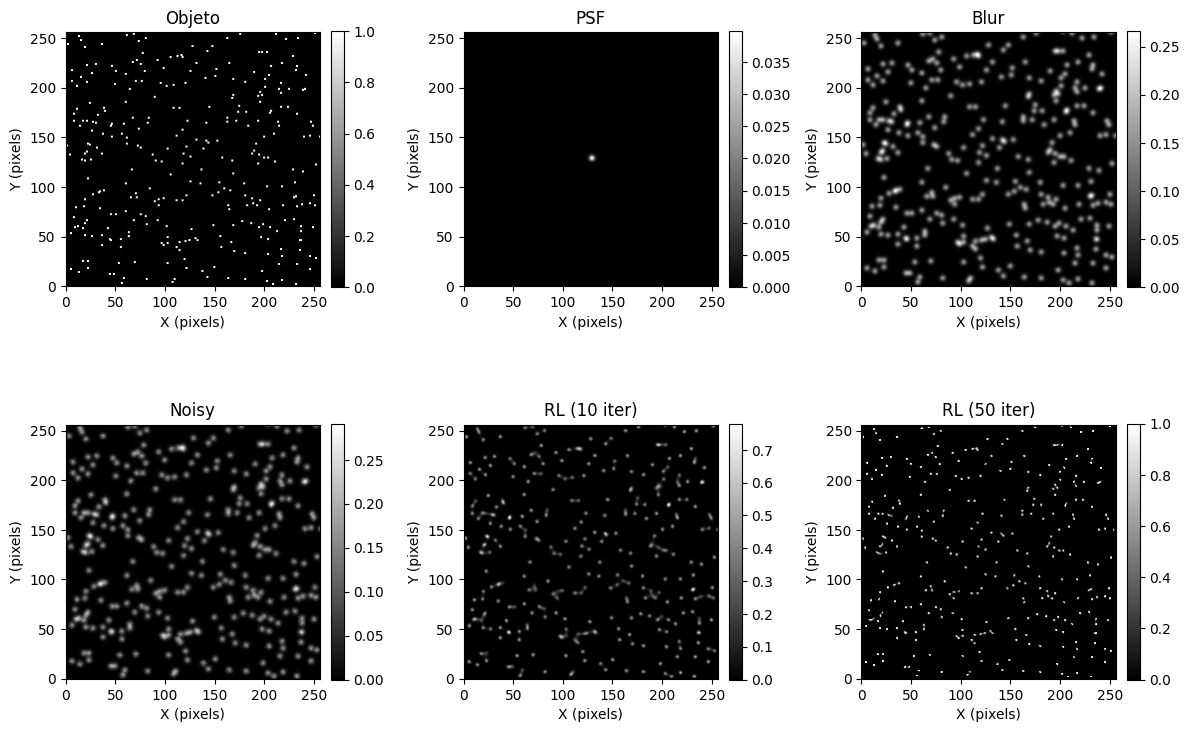

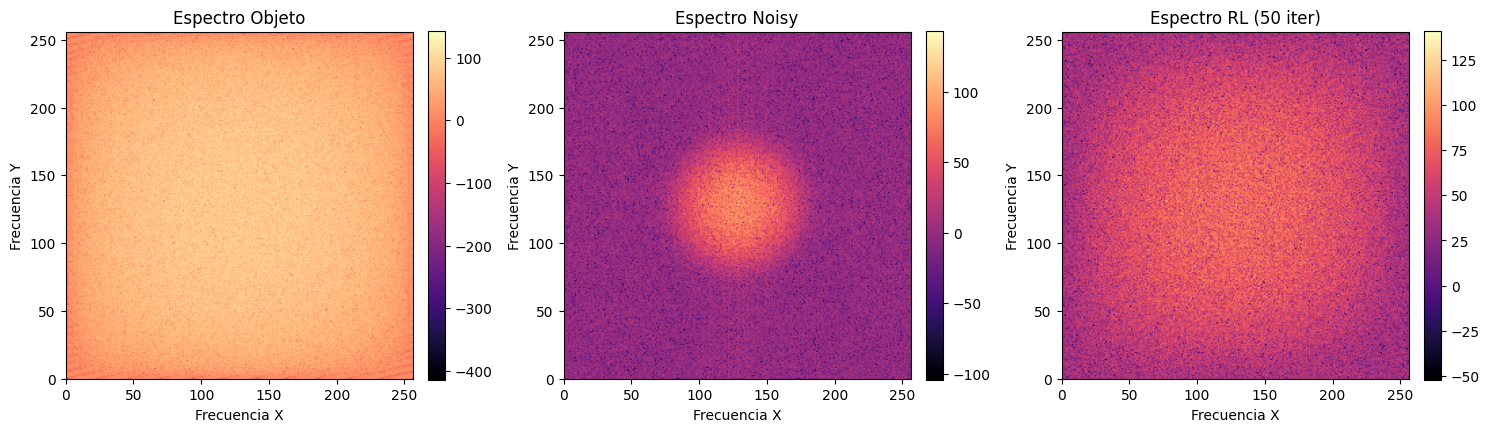

In [ ]:
obj = generar_puntos_aleatorios(densidad_puntos=0.02, punto_size=2) # Usamos la función de puntos aleatorios con densidad

# Ahora el PSF tendrá el mismo tamaño que el objeto
psf = psf_gaussiana(size=obj.shape[0], sigma=2)

obj, blur, noisy, rl_10, rl_50 = pipeline(obj, psf, guardar=True)


# =========================================================
# 9. DESCARGA (COLAB)
# =========================================================

import zipfile
from google.colab import files

with zipfile.ZipFile("resultados.zip", "w") as z:
    z.write("obj.tif")
    z.write("psf.tif")
    z.write("blur.tif")
    z.write("noisy.tif")
    z.write("rl_10.tif")
    z.write("rl_50.tif")

#files.download("resultados.zip")